## Trabajo en clase 01: Simulación de un sistema planetario

**Nombre completo:**
Marissa Crespo Soto
**Carné:**
C5E563
### Fecha de entrega
Jueves 10 de setiembre de 2026, 23:59 h.


### Instrucciones generales
Implemente y documente las funciones solicitadas:

- `aceleracion_gravitacional`: calcula la aceleración gravitacional de un cuerpo celeste debida a la masa central **(30 puntos)**.
- `actualizar`: aplica un paso temporal del método Velocity Verlet **(40 puntos)**.

- Además, demuestre el funcionamiento del código simulando varios planetas con distintas posiciones iniciales y diferentes factores de velocidad. Interprete los resultados desde el punto de vista físico **(30 puntos)**.

**Total:** 100 puntos.

### Formato de entrega
Guarde el notebook en una carpeta llamanda `01-Trabajo_en_clase` y subir a su repositorio privado en GitHub.


# Simulación de movimiento planetario

## Introducción

El movimiento de los planetas alrededor del Sol puede modelarse utilizando la ley de gravitación universal de Newton:

$$
F = \frac{G M m}{r^2}.
$$

En términos de aceleración, esto implica:

$$
\vec{a} = -\frac{GM}{r^3}\vec{r},
$$

donde $\vec{r}$ es el vector posición del planeta respecto al Sol. Esta ecuación es la base de la simulación numérica.

## Unidades astronómicas

Para simplificar los cálculos, se utilizan unidades naturales del problema:

- Distancia en unidades astronómicas (AU).
- Tiempo en años.
- Masa en masas solares.

Con esta elección:

- La distancia Tierra-Sol es $r = 1$.
- El período orbital de la Tierra es $T = 1$.
- La masa del Sol es $M = 1$.

Usando el hecho de que en una órbita circular:

$$
\frac{GM}{r^2} = \frac{v^2}{r},
$$

y que $v = 2\pi r / T$, se obtiene:

$$
GM = \frac{4\pi^2 r^3}{T^2}.
$$

Evaluando para la Tierra ($r=1$, $T=1$, $M=1$), resulta:

$$
G = 4\pi^2.
$$

Esta elección elimina constantes innecesarias y permite que la tercera ley de Kepler tome la forma simple:

$$
T^2 = r^3.
$$

## Control de la forma de la órbita: `velocity_factor`

En la simulación, la velocidad inicial de cada partícula se define como:

$$
v_0 = f\, v_{\mathrm{circ}},
$$

donde $f$ es el parámetro `velocity_factor` y

$$
v_{\mathrm{circ}} = \sqrt{\frac{GM}{r}}
$$

es la velocidad necesaria para una órbita circular.

Este parámetro controla directamente la energía total del sistema:

$$
E = \frac{1}{2} m v^2 - \frac{GMm}{r}
= \frac{GMm}{r}\left(\frac{f^2}{2} - 1\right).
$$

Dependiendo del valor de $f$:

| <span style="width: 120px; display: inline-block;">Valor de $f$</span> | Trayectoria | Energía Total ($E$) | Comportamiento en la Simulación | Estado en el Infinito ($r \to \infty$) |
| :--- | :--- | :--- | :--- | :--- |
| **$0 < f < 1$** | **Elipse** | $E < 0$ (Ligada) | Inicia en el **afelio** (punto más lejano) y cae hacia el centro. | No llega al infinito (órbita cerrada). |
| **$f = 1$** | **Círculo** | $E < 0$ (Ligada) | Equilibrio perfecto. Radio constante. | No llega al infinito (órbita cerrada). |
| **$1 < f < \sqrt{2}$** | **Elipse** | $E < 0$ (Ligada) | Inicia en el **perihelio** (punto más cercano) y se aleja. | No llega al infinito (órbita cerrada). |
| **$f = \sqrt{2}$** | **Parábola** | $E = 0$ (Crítica) | Alcanza la velocidad de escape justa. Trayectoria abierta. | Llega con **velocidad cero** ($v_{\infty} = 0$). |
| **$f > \sqrt{2}$** | **Hipérbola** | $E > 0$ (Libre) | Escapa con exceso de velocidad. Trayectoria abierta. | Llega con **velocidad residual** ($v_{\infty} > 0$). |

Desde el punto de vista físico, el caso circular es especial: la velocidad es exactamente la necesaria para mantener constante la distancia al Sol. Cualquier desviación de este valor introduce una componente radial en el movimiento, lo que produce una oscilación en la distancia y da lugar a una órbita elíptica.



## Integración numérica: método de Velocity Verlet

La ecuación de movimiento del sistema es:

$$
\frac{d^2 \vec{r}}{dt^2} = \vec{a}(\vec{r}) = -\frac{GM}{r^3}\vec{r}.
$$

Esta ecuación diferencial de segundo orden se puede resolver numéricamente mediante el método de **Velocity Verlet**, el cual es ampliamente utilizado en simulaciones físicas de mecánica clásica gracias a su buena conservación de la energía (es un método **simpléctico**).

El algoritmo se compone de tres pasos:

1. Calcular la aceleración en la posición actual:

$$
\vec{a}_n = \vec{a}(\vec{r}_n)
$$

2. Actualizar la posición:

$$
\vec{r}_{n+1} = \vec{r}_n + \vec{v}_n \Delta t + \frac{1}{2}\vec{a}_n \Delta t^2
$$

3. Calcular la nueva aceleración:

$$
\vec{a}_{n+1} = \vec{a}(\vec{r}_{n+1})
$$

4. Actualizar la velocidad:

$$
\vec{v}_{n+1} = \vec{v}_n + \frac{1}{2}(\vec{a}_n + \vec{a}_{n+1}) \Delta t
$$

In [1]:
%matplotlib inline
from matplotlib import rc
import matplotlib as mpl

rc('animation', html='jshtml')
mpl.rcParams["animation.embed_limit"] = 50000000  # 50 MB

In [2]:
from animar_planetas import animar, graficar_orbitas


In [26]:
import numpy as np
from animar_planetas import animar, graficar_orbitas


class CuerpoCeleste:
    """
    Representa un cuerpo celeste orbitando una masa central fija en el origen.
    """
    def __init__(self, nombre, masa, posicion, velocidad, color="blue"):
        self.nombre = nombre
        self.masa = masa
        self.posicion = np.array(posicion, dtype=float)
        self.velocidad = np.array(velocidad, dtype=float)
        self.color = color
        self.historial_posiciones = [self.posicion.copy()]

    def aceleracion_gravitacional(self, masa_central, G=4 * np.pi**2):
        
        r_vec = self.posicion
        r_norma = np.linalg.norm(r_vec)
        r = r_norma
        M = masa_central  

                
        aceleracion = -(((G*M)/(r**3))*r_vec)
        
        """
        TODO: implementar aceleración gravitacional (vector).
        """
        return aceleracion
    


    def actualizar(self, dt, masa_central, G=4 * np.pi**2):
        a_inicial = self.aceleracion_gravitacional(masa_central)
        self.posicion = self.posicion + self.velocidad*dt + (a_inicial*(dt**2))/2
        a_final = self.aceleracion_gravitacional(masa_central)
        self.velocidad = self.velocidad + ((a_inicial + a_final)*dt)/2
      
        self.historial_posiciones.append(self.posicion.copy())
        
        
        """
        TODO: implementar un paso de integración con Velocity Verlet.
        Para que las funciones de graficación funcionen correctamente, 
        es importante que se actualice el atributo `historial_posiciones` 
        con la nueva posición después de cada paso.
        """
        return 
    


In [27]:
class SimulacionSistemaSolar:
    def __init__(self, masa_central=1.0, dt=0.001, tiempo_total=2.0):
        self.masa_central = masa_central
        self.dt = dt
        self.tiempo_total = tiempo_total
        self.num_pasos = int(tiempo_total / dt)
        self.cuerpos = []

    def agregar_cuerpo(self, cuerpo):
        self.cuerpos.append(cuerpo)

    def agregar_planeta_por_posicion_inicial(self, nombre, x0, y0, factor_velocidad=1.0,
                                             masa=0.0, color="blue", sentido_horario=False):

        r0_vec = np.array([x0, y0], dtype=float)
        r0 = np.linalg.norm(r0_vec)

        if r0 == 0:
            raise ValueError("La posición inicial no puede ser (0,0).")

        G = 4 * np.pi**2
        v_circular = np.sqrt(G * self.masa_central / r0)
        v0 = factor_velocidad * v_circular

        # Vector unitario radial
        r_hat = r0_vec / r0

        # Vector unitario tangencial perpendicular a r_hat
        if sentido_horario:
            t_hat = np.array([r_hat[1], -r_hat[0]])
        else:
            t_hat = np.array([-r_hat[1], r_hat[0]])

        velocidad = v0 * t_hat

        cuerpo = CuerpoCeleste(
            nombre=nombre,
            masa=masa,
            posicion=[x0, y0],
            velocidad=velocidad,
            color=color
        )
        self.agregar_cuerpo(cuerpo)

    def ejecutar(self):
        for _ in range(self.num_pasos):
            for cuerpo in self.cuerpos:
                cuerpo.actualizar(self.dt, self.masa_central)


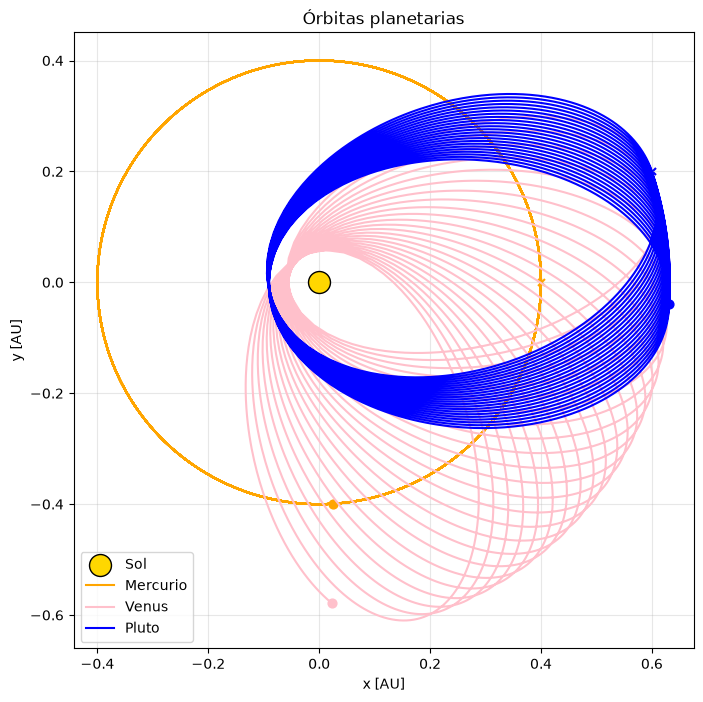

In [34]:
sim = SimulacionSistemaSolar(dt=0.001, tiempo_total=5.0)

sim.agregar_planeta_por_posicion_inicial(
    nombre="Mercurio",
    x0=0.4,
    y0=0.0,
    factor_velocidad=1.0,
    color="orange"
)

sim.agregar_planeta_por_posicion_inicial(
    nombre="Venus",
    x0=0.6,
    y0=0.2,
    factor_velocidad=0.4,
    color="pink"
)
sim.agregar_planeta_por_posicion_inicial(
    nombre="Pluto",
    x0=0.6,
    y0=0.2,
    factor_velocidad=0.5,
    color="blue"
)


sim.ejecutar()
graficar_orbitas(sim)

# Descomente para ver la animación (puede tardar un poco en generarse)
ani = animar(sim, interval=30, show=False, max_frames=200, blit=False)
 #ani


Análisis Físico: 
